# Portfolio - Base Price Modeling for Short-Term Rentals

Este notebook resolve o projeto de portfólio de ciência de dados usando as duas bases locais:

- `airbnb_apart (1).csv`: atributos estruturais e metadados dos anúncios.
- `airbnb_prices (1).csv`: cotações por janela de estadia, preços e avaliações.

A solução estima um **preço base estrutural por diária**. O foco é capturar valor de imóvel, localização e qualidade observável, sem transformar o problema em precificação dinâmica por data, evento, feriado ou ocupação.

## 0. Leitura dos requisitos do projeto

O projeto foi organizado para cobrir:

1. Limpeza e pré-processamento das bases.
2. Análise exploratória cobrindo distribuição de preço, outliers, extremos, preço por bairro e outros insights relevantes.
3. Decisão clara sobre `check_in`, `check_out`, `los` e `reference_date`, para não modelar sazonalidade/dinâmica.
4. Engenharia de atributos, incluindo tratamento geográfico.
5. Treino de modelo para estimar preço base.
6. Validação com métricas justificadas.
7. Avaliação por segmentos.
8. Interpretação dos drivers de preço, incluindo impacto aproximado de +1 quarto, +1 banheiro e mudança de localização.
9. Discussão de estabilidade/generalização, limitações, produção e extensões para pricing dinâmico.

A estratégia abaixo segue esses pontos como uma trilha auditável.

In [1]:
from pathlib import Path
import json
import re
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import HuberRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "airbnb_apart (1).csv").exists() and (ROOT.parent / "airbnb_apart (1).csv").exists():
    ROOT = ROOT.parent
DATA_APART = ROOT / "airbnb_apart (1).csv"
DATA_PRICES = ROOT / "airbnb_prices (1).csv"
OUT = ROOT / "outputs"
FIG_DIR = OUT / "figures"
TABLE_DIR = OUT / "tables"
MODEL_DIR = ROOT / "models"

for path in [OUT, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Workspace: {ROOT}")
print(f"Arquivos encontrados: {DATA_APART.name}, {DATA_PRICES.name}")

Workspace: D:\dev\portfolio-pricing
Arquivos encontrados: airbnb_apart (1).csv, airbnb_prices (1).csv


## 1. Carga e auditoria inicial

A primeira etapa verifica tamanho, tipos, nulos, duplicatas e cobertura do `id` entre as bases. Isso define a unidade correta de modelagem e evita vazamento por repetição de linhas de preço.

In [2]:
apart_raw = pd.read_csv(DATA_APART).drop(columns=["Unnamed: 0"], errors="ignore")
prices_raw = pd.read_csv(DATA_PRICES).drop(columns=["Unnamed: 0"], errors="ignore")

id_intersection = set(apart_raw["id"]).intersection(set(prices_raw["id"]))

audit_rows = []
for name, data in [("airbnb_apart", apart_raw), ("airbnb_prices", prices_raw)]:
    audit_rows.append(
        {
            "dataset": name,
            "rows": len(data),
            "columns": data.shape[1],
            "unique_ids": data["id"].nunique(),
            "duplicated_rows": int(data.duplicated().sum()),
            "memory_mb": round(data.memory_usage(deep=True).sum() / 1e6, 1),
        }
    )

audit = pd.DataFrame(audit_rows)
coverage = pd.DataFrame(
    [
        {"metric": "ids em airbnb_apart", "value": apart_raw["id"].nunique()},
        {"metric": "ids em airbnb_prices", "value": prices_raw["id"].nunique()},
        {"metric": "ids com dados nas duas bases", "value": len(id_intersection)},
        {"metric": "apartamentos sem preço observado", "value": apart_raw["id"].nunique() - len(id_intersection)},
        {"metric": "ids de preço sem metadados", "value": prices_raw["id"].nunique() - len(id_intersection)},
    ]
)

missing_apart = apart_raw.isna().mean().sort_values(ascending=False).rename("missing_rate").reset_index().rename(columns={"index": "column"})
missing_prices = prices_raw.isna().mean().sort_values(ascending=False).rename("missing_rate").reset_index().rename(columns={"index": "column"})

audit.to_csv(TABLE_DIR / "data_audit.csv", index=False)
coverage.to_csv(TABLE_DIR / "id_coverage.csv", index=False)
missing_apart.to_csv(TABLE_DIR / "missing_airbnb_apart.csv", index=False)
missing_prices.to_csv(TABLE_DIR / "missing_airbnb_prices.csv", index=False)

display(audit)
display(coverage)
display(missing_apart.head(10))
display(missing_prices.head(12))

,dataset,rows,columns,unique_ids,duplicated_rows,memory_mb
0,airbnb_apart,19068,16,19068,0,12.4
1,airbnb_prices,1090726,22,11494,0,431.9


,metric,value
0,ids em airbnb_apart,19068
1,ids em airbnb_prices,11494
2,ids com dados nas duas bases,11494
3,apartamentos sem preço observado,7574
4,ids de preço sem metadados,0


,column,missing_rate
0,beds,0.006975
1,bathrooms,0.000052
2,id,0.000000
3,realty_type,0.000000
4,listing_obj_type,0.000000
5,kicker_content_message,0.000000
6,airbnb_neighborhood,0.000000
7,ad_title,0.000000
8,is_new_listing,0.000000
9,is_superhost,0.000000


,column,missing_rate
0,airbnb_service_fee,1.000000
1,cleaning_fee,1.000000
2,original_price,0.503220
3,discounted_price,0.503220
4,main_price,0.496780
5,discount,0.337803
6,price_total_with_cleaning,0.289866
7,los,0.000000
8,reference_date,0.000000
9,check_in,0.000000


### Observações da auditoria

- A base de preços tem várias linhas por anúncio; portanto, a validação precisa ser por anúncio, não por linha de cotação.
- Nem todos os anúncios têm preço observado. O modelo usa apenas anúncios com alvo observável, mas uma implementação em produção aceitaria novos imóveis desde que tenham os atributos estruturais necessários.
- `cleaning_fee` e `airbnb_service_fee` estão completamente ausentes nesta extração; por isso não são usados para o alvo.
- `bathrooms` vem como texto e precisa ser convertido para número.

In [3]:
def parse_bathroom(value):
    # Converte strings como '1', '1.5' e 'Half-bath' para número.
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if "half" in text:
        return 0.5
    match = re.search(r"\d+(?:\.\d+)?", text)
    return float(match.group()) if match else np.nan


def strip_accents(value):
    if pd.isna(value):
        return ""
    text = str(value).lower()
    return "".join(ch for ch in unicodedata.normalize("NFKD", text) if not unicodedata.combining(ch))


def haversine_km(lat1, lon1, lat2, lon2):
    # Distância geodésica aproximada em km.
    radius_km = 6371.0088
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * radius_km * np.arcsin(np.sqrt(a))


def regression_metrics(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 1, None)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "MdAPE": np.median(np.abs((y_true - y_pred) / y_true)) * 100,
        "R2_log": r2_score(np.log(y_true), np.log(y_pred)),
        "Bias": float(np.mean(y_pred - y_true)),
    }


def rounded_display(data, decimals=2):
    display(data.round(decimals) if hasattr(data, "round") else data)

## 2. Construção do alvo estrutural

A base de preços tem janelas de estadia (`check_in`, `check_out`, `los`) e datas de consulta (`reference_date`). Esses campos capturam efeitos dinâmicos: sazonalidade, feriados, antecedência, eventos e descontos por duração. Como o objetivo é **preço base estrutural**, eles não entram como features do modelo final.

Uso essas variáveis apenas para construir e auditar o alvo:

1. Removo linhas de preço extremamente improváveis usando os percentis 0,1% e 99,9% de `price_per_night`.
2. Agrego por `id` com a **mediana** de `price_per_night`, que é mais robusta que média contra picos de calendário e erros de scrape.
3. Exijo pelo menos 5 cotações por anúncio para reduzir ruído no alvo.
4. Faço filtros de sanidade geográfica e estrutural, removendo contaminações claras e mantendo a cauda válida de praia/premium.
5. Não faço corte final do alvo agregado; a robustez vem do uso de `log(base_price)`, perda absoluta e segmentação explícita de mercado.

In [4]:
prices = prices_raw.copy()
for col in ["check_in", "check_out", "reference_date", "extraction_date"]:
    prices[col] = pd.to_datetime(prices[col], errors="coerce")

positive_prices = prices.loc[prices["price_per_night"].gt(0)].copy()
row_price_low, row_price_high = positive_prices["price_per_night"].quantile([0.001, 0.999])
prices_clean = positive_prices.loc[positive_prices["price_per_night"].between(row_price_low, row_price_high)].copy()

los_diagnostic = (
    positive_prices.groupby("los")["price_per_night"]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .reset_index()
)

checkin_diagnostic = (
    positive_prices.groupby(["los", "check_in"], as_index=False)["price_per_night"]
    .median()
    .rename(columns={"price_per_night": "median_price_per_night"})
)

base_target = (
    prices_clean.groupby("id")
    .agg(
        base_price=("price_per_night", "median"),
        price_iqr=("price_per_night", lambda s: s.quantile(0.75) - s.quantile(0.25)),
        n_price_obs=("price_per_night", "size"),
        los3_share=("los", lambda s: float((s == 3).mean())),
        review_count=("review_count", "max"),
    )
    .reset_index()
)

df = apart_raw.merge(base_target, on="id", how="inner")
df["bathrooms_num"] = df["bathrooms"].apply(parse_bathroom)

market_center_lat = df["lat"].median()
market_center_lon = df["lon"].median()
df["distance_to_market_center_km"] = haversine_km(market_center_lat, market_center_lon, df["lat"], df["lon"])

target_build_summary = pd.DataFrame(
    [
        {"step": "linhas de preço originais", "rows": len(prices_raw), "unique_ids": prices_raw["id"].nunique()},
        {"step": "linhas com price_per_night positivo", "rows": len(positive_prices), "unique_ids": positive_prices["id"].nunique()},
        {"step": "linhas após filtro p0.1-p99.9", "rows": len(prices_clean), "unique_ids": prices_clean["id"].nunique()},
        {"step": "alvo agregado por anúncio", "rows": len(base_target), "unique_ids": base_target["id"].nunique()},
        {"step": "merge alvo + atributos", "rows": len(df), "unique_ids": df["id"].nunique()},
    ]
)

target_build_summary.to_csv(TABLE_DIR / "target_build_summary.csv", index=False)
los_diagnostic.to_csv(TABLE_DIR / "los_price_diagnostic.csv", index=False)
checkin_diagnostic.to_csv(TABLE_DIR / "checkin_price_diagnostic.csv", index=False)

print(f"Filtro de preço por linha: {row_price_low:,.2f} a {row_price_high:,.2f}")
print(f"Centro robusto do mercado: lat={market_center_lat:.6f}, lon={market_center_lon:.6f}")
display(target_build_summary)
rounded_display(los_diagnostic)

Filtro de preço por linha: 101.53 a 63,077.00
Centro robusto do mercado: lat=-23.564542, lon=-46.661510


,step,rows,unique_ids
0,linhas de preço originais,1090726,11494
1,linhas com price_per_night positivo,1090726,11494
2,linhas após filtro p0.1-p99.9,1088557,11492
3,alvo agregado por anúncio,11492,11492
4,merge alvo + atributos,11492,11492


,los,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
0,3,102980.0,512.62,609.95,89.67,195.25,254.33,321.67,539.33,1347.5,2901.31,12679.0
1,15,987746.0,1174.69,5028.39,81.20,159.60,213.27,274.47,452.13,4519.0,13383.00,396000.0


## 3. EDA: preço, outliers, bairro e geografia

A EDA abaixo é feita antes do filtro final de modelagem para deixar visíveis os problemas do mercado observado: cauda de preço, anúncios extremos e coordenadas fora do núcleo geográfico.

In [5]:
target_distribution = df["base_price"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995]).to_frame("base_price")
geo_distribution = df["distance_to_market_center_km"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995]).to_frame("distance_to_market_center_km")

neighborhood_prices_raw = (
    df.groupby("airbnb_neighborhood")
    .agg(n=("id", "size"), median_price=("base_price", "median"), mean_price=("base_price", "mean"), median_distance_km=("distance_to_market_center_km", "median"))
    .query("n >= 30")
    .sort_values("median_price", ascending=False)
    .reset_index()
)

extreme_listings = (
    df.sort_values("base_price", ascending=False)
    [["id", "airbnb_neighborhood", "ad_title", "guests", "bedrooms", "beds", "bathrooms", "lat", "lon", "distance_to_market_center_km", "base_price", "n_price_obs"]]
    .head(25)
)

remote_locations = (
    df.loc[df["distance_to_market_center_km"] > 40]
    .groupby("airbnb_neighborhood")
    .agg(n=("id", "size"), median_distance_km=("distance_to_market_center_km", "median"), median_price=("base_price", "median"))
    .sort_values("n", ascending=False)
    .reset_index()
)

target_distribution.to_csv(TABLE_DIR / "raw_target_distribution.csv")
geo_distribution.to_csv(TABLE_DIR / "geo_distance_distribution.csv")
neighborhood_prices_raw.to_csv(TABLE_DIR / "raw_neighborhood_prices.csv", index=False)
extreme_listings.to_csv(TABLE_DIR / "extreme_listings.csv", index=False)
remote_locations.to_csv(TABLE_DIR / "remote_location_groups.csv", index=False)

display(target_distribution.round(2))
display(geo_distribution.round(2))
print("Bairros/regiões com maior mediana de preço, antes do filtro final:")
display(neighborhood_prices_raw.head(15).round(2))
print("Anúncios extremos:")
display(extreme_listings.round(2))
print("Grupos geográficos acima de 40 km do centro robusto (diagnóstico para segmentação):")
display(remote_locations.head(20).round(2))

,base_price
count,11492.00
mean,627.97
std,2005.65
min,101.67
1%,133.47
5%,164.37
25%,219.92
50%,278.00
75%,421.38
95%,1832.33


,distance_to_market_center_km
count,11492.00
mean,90.26
std,789.32
min,0.08
50%,4.45
75%,7.47
90%,14.05
95%,70.97
99%,7863.64
99.5%,7869.20


Bairros/regiões com maior mediana de preço, antes do filtro final:


,airbnb_neighborhood,n,median_price,mean_price,median_distance_km
0,Bertioga,119,2426.33,5436.78,71.57
1,Riviera De Sao Lourenco,285,2074.67,4345.56,70.10
2,Guadalajara,87,537.73,896.83,7868.53
3,Morumbi,58,438.02,629.09,6.80
4,Vila Olímpia,226,402.00,602.77,4.33
5,Alvinópolis,155,370.67,514.30,0.83
6,Higienópolis,32,364.80,480.19,2.38
7,Paraíso,65,340.67,554.88,1.63
8,Jardim Paulista,450,340.00,632.13,0.96
9,Pinheiros,464,324.00,456.45,2.77


Anúncios extremos:


,id,airbnb_neighborhood,ad_title,guests,bedrooms,beds,bathrooms,lat,lon,distance_to_market_center_km,base_price,n_price_obs
1163,17246572,Riviera De Sao Lourenco,"Luxurious apartment with its ""foot in the sand""",9,5,7.0,5.5,-23.80,-46.01,70.88,56551.00,45
4501,1264614384319720207,Bertioga,"High Standard Apartment, 80 meters from the beach",10,4,6.0,3,-23.80,-46.00,71.63,47069.50,120
2861,33855506,Riviera de São Lourenço,Riviera pé areia vista mar 3Dorm+Suite Emp+QdT...,8,4,5.0,4,-23.80,-46.00,71.71,46896.00,45
248,52538734,Riviera De Sao Lourenco,"4 en-suites, high standard, 220 m2, shared Club",9,4,6.0,5,-23.81,-46.03,69.35,40160.00,45
3375,758126076571762270,Riviera De Sao Lourenco,Riviera Front Unforgettable view,10,4,8.0,3,-23.80,-46.02,70.09,39926.00,24
2276,1565346995823524875,Bertioga,Beachfront apartment Riviera de São Lourenço,12,4,4.0,4,-23.80,-46.02,70.27,39921.00,51
739,1467522776911479965,Bertioga,"4-Suite Beachfront Apartment, Module 8 Riviera",8,4,5.0,3,-23.80,-46.01,71.58,39910.00,33
6472,45686837,Riviera De Sao Lourenco,Penthouse with a sea view,12,4,8.0,5,-23.80,-46.03,69.45,38942.00,63
179,1609577303762848147,Bertioga,In editing,8,4,6.0,3,-23.81,-46.03,69.46,36815.00,15
5373,1028349208859059477,Bertioga,Luxury Sea View Apartment 100 m from the Beach,8,4,5.0,3,-23.80,-46.00,72.08,34427.00,24


Grupos geográficos acima de 40 km do centro robusto (diagnóstico para segmentação):


,airbnb_neighborhood,n,median_distance_km,median_price
0,Riviera De Sao Lourenco,285,70.10,2074.67
1,Bertioga,118,71.58,2438.58
2,Guadalajara,87,7868.53,537.73
3,Campinas,83,84.69,255.80
4,Americana,48,114.61,252.12
5,Zapopan,29,7872.99,833.53
6,Centro,24,114.61,142.32
7,Lapa,15,80.57,168.60
8,São Lourenço,15,71.80,3539.47
9,Ourinhos,14,334.12,210.27


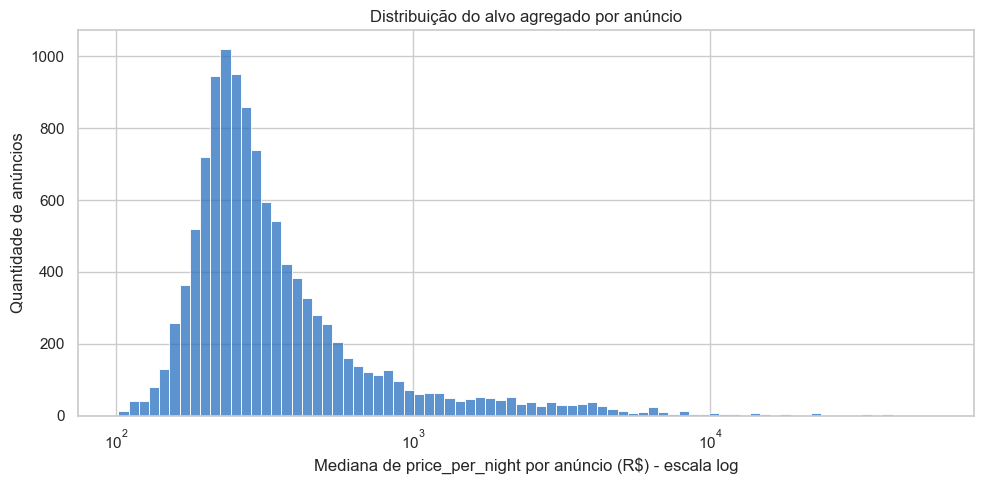

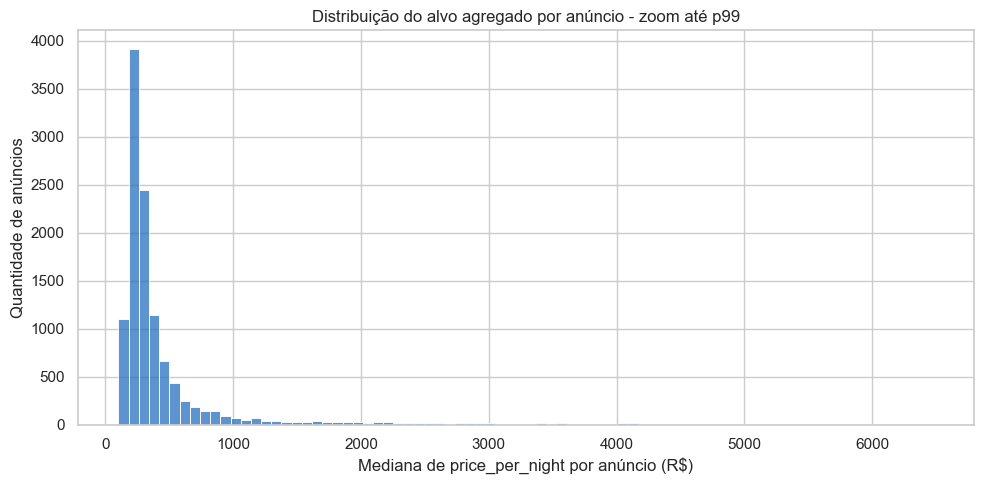

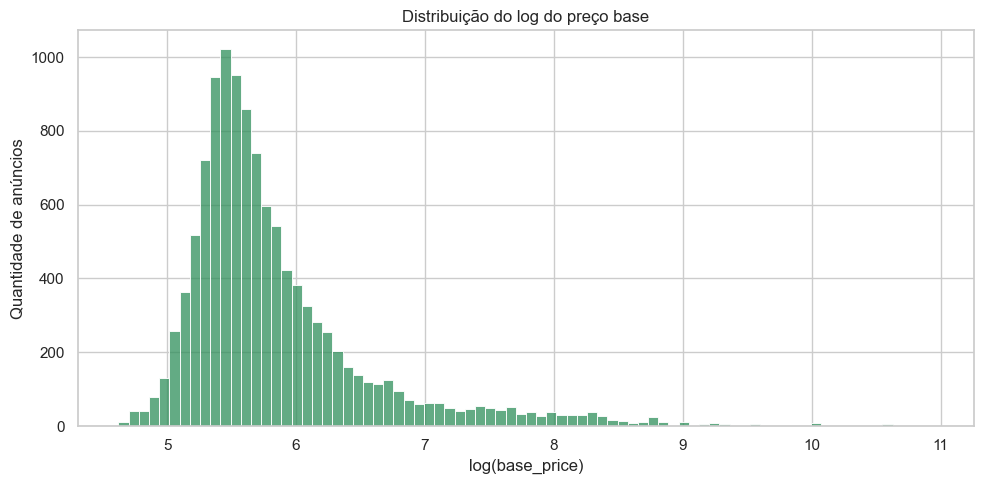

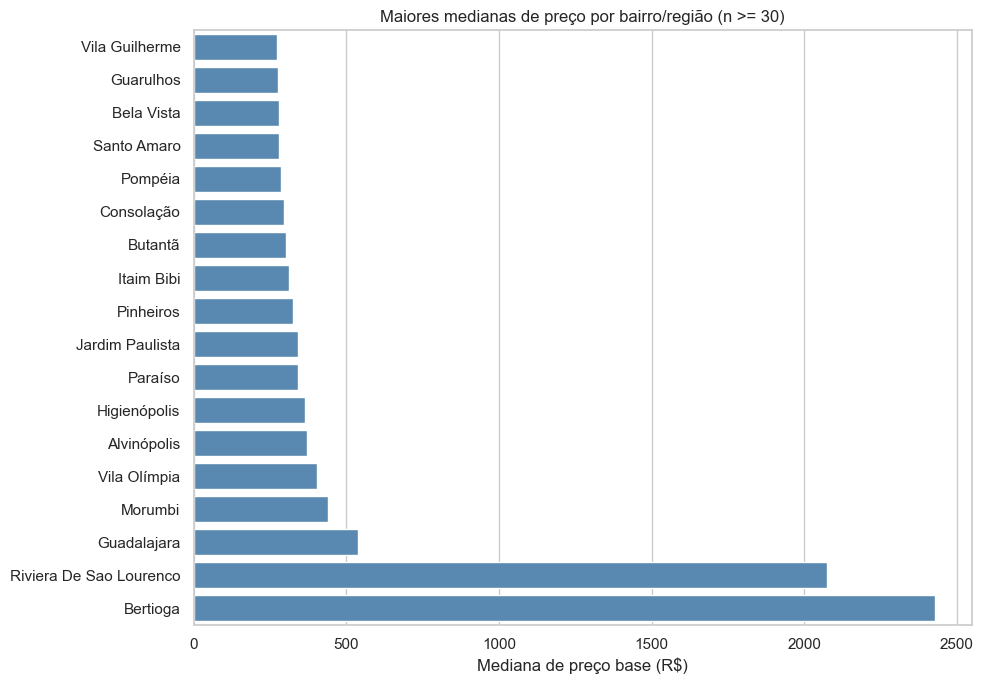

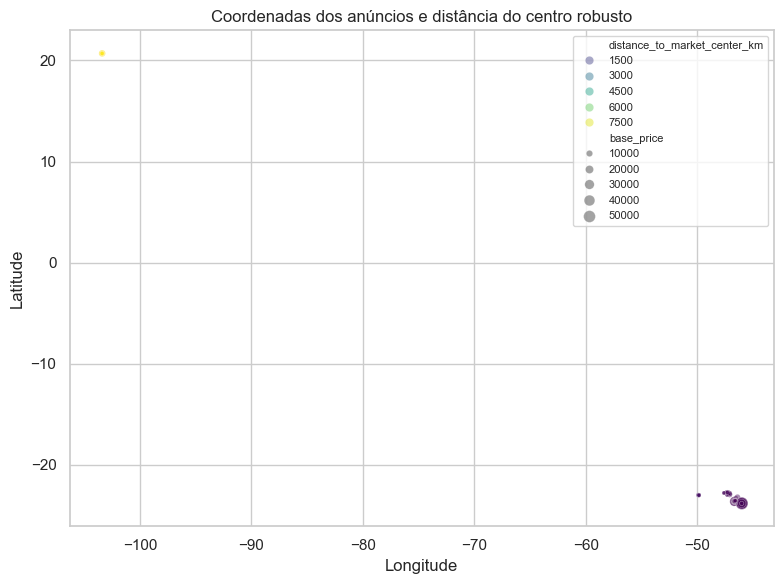

In [6]:
# A distribuição tem cauda longa. Em escala linear o miolo fica espremido
# perto de zero; por isso usamos eixo X em log para o diagnóstico bruto.
plt.figure(figsize=(10, 5))
sns.histplot(df["base_price"], bins=80, log_scale=(True, False), color="#276fbf")
plt.title("Distribuição do alvo agregado por anúncio")
plt.xlabel("Mediana de price_per_night por anúncio (R$) - escala log")
plt.ylabel("Quantidade de anúncios")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_raw_target_distribution.png", dpi=160)
plt.show()

# Visualização complementar: zoom no corpo da distribuição até p99.
price_p99 = df["base_price"].quantile(0.99)
plt.figure(figsize=(10, 5))
sns.histplot(df.loc[df["base_price"] <= price_p99, "base_price"], bins=80, color="#276fbf")
plt.title("Distribuição do alvo agregado por anúncio - zoom até p99")
plt.xlabel("Mediana de price_per_night por anúncio (R$)")
plt.ylabel("Quantidade de anúncios")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_raw_target_distribution_zoom_p99.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log(df["base_price"]), bins=80, color="#2f8f5b")
plt.title("Distribuição do log do preço base")
plt.xlabel("log(base_price)")
plt.ylabel("Quantidade de anúncios")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_log_target_distribution.png", dpi=160)
plt.show()

plot_neighborhood = neighborhood_prices_raw.head(18).sort_values("median_price")
plt.figure(figsize=(10, 7))
sns.barplot(data=plot_neighborhood, x="median_price", y="airbnb_neighborhood", color="#4b8bbe")
plt.title("Maiores medianas de preço por bairro/região (n >= 30)")
plt.xlabel("Mediana de preço base (R$)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_price_by_neighborhood_raw.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 6))
sample_geo = df.sample(min(len(df), 7000), random_state=RANDOM_STATE)
sns.scatterplot(data=sample_geo, x="lon", y="lat", hue="distance_to_market_center_km", size="base_price", sizes=(8, 80), alpha=0.45, palette="viridis")
plt.title("Coordenadas dos anúncios e distância do centro robusto")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_geo_scatter.png", dpi=160)
plt.show()

### Decisões de limpeza após a EDA

A EDA mostra três problemas relevantes:

- A cauda de preço é muito longa, com diárias agregadas acima de vários milhares de reais. Parte disso é luxo, mas parte parece efeito de dados e janelas específicas.
- Há coordenadas muito distantes do núcleo de São Paulo, apesar de `city` ser constante. Removo apenas contaminações fortes acima de 150 km, mantendo Bertioga/Riviera como segmento de praia/premium.
- Existem inconsistências estruturais, como número de quartos muito alto para `Entire rental unit`. Faço filtros amplos de sanidade e caps robustos para não treinar o modelo em anúncios multiunidade ou erros de scrape.

## 4. Feature engineering e amostra final de modelagem

Features usadas no modelo final:

- Capacidade e estrutura: hóspedes, quartos, camas, banheiros e razões derivadas.
- Geografia: bairro Airbnb, latitude, longitude e distância ao centro robusto do mercado.
- Metadados do anúncio: superhost, novo anúncio e tipo do objeto.
- Texto simples do título/descrição: flags para studio, luxo, vista, metrô, garagem, piscina, academia, Wi-Fi, ar-condicionado, praia e varanda.

Ratings e reviews foram analisados, mas não entram no modelo final escolhido: eles podem melhorar pouco a previsão, porém reduzem portabilidade para imóveis novos, onde esses sinais podem não existir.

In [7]:
def add_text_features(data):
    out = data.copy()
    text_norm = (
        out["ad_title"].fillna("")
        + " "
        + out["kicker_content_message"].fillna("")
        + " "
        + out["airbnb_neighborhood"].fillna("")
    ).map(strip_accents)
    keyword_patterns = {
        "has_studio": r"\bstudio\b",
        "has_loft": r"\bloft\b",
        "has_luxury": r"luxo|luxury|alto padrao|high standard|sofistic",
        "has_view": r"vista|view|mar",
        "has_metro": r"metro|subway",
        "has_parking": r"garagem|parking|vaga",
        "has_pool": r"piscina|pool",
        "has_gym": r"academia|gym|fitness",
        "has_wifi": r"wi-?fi|internet",
        "has_air_conditioning": r"ar cond|air cond|a/c|ar c\.?",
        "has_beach": r"praia|beach|rivier|pe na areia|bertioga|sao lourenco",
        "has_balcony": r"varanda|balcony|terrace|terraco",
    }
    for col, pattern in keyword_patterns.items():
        out[col] = text_norm.str.contains(pattern, regex=True, na=False).astype(int)
    out["title_len"] = out["ad_title"].fillna("").str.len()
    out["title_word_count"] = out["ad_title"].fillna("").str.split().str.len()
    out["description_len"] = out["kicker_content_message"].fillna("").str.len()
    return out


def add_structural_features(data):
    out = add_text_features(data)
    out["is_superhost_int"] = out["is_superhost"].astype(int)
    out["is_new_listing_int"] = out["is_new_listing"].astype(int)
    out["beds"] = out["beds"].astype(float)
    out["market_segment"] = np.select(
        [out["has_beach"].eq(1), out["distance_to_market_center_km"].gt(40)],
        ["beach_premium", "extended_market"],
        default="urban_core",
    )
    out["guests_model"] = out["guests"].clip(1, 16)
    out["bedrooms_model"] = out["bedrooms"].clip(1, 10)
    out["beds_model"] = out["beds"].clip(1, 30)
    out["bathrooms_model"] = out["bathrooms_num"].clip(0.5, 10)
    out["bath_per_bedroom"] = out["bathrooms_model"] / out["bedrooms_model"].clip(lower=1)
    out["beds_per_guest"] = out["beds_model"] / out["guests_model"].clip(lower=1)
    out["guests_per_bedroom"] = out["guests_model"] / out["bedrooms_model"].clip(lower=1)
    return out


model_df = add_structural_features(df)

filter_report = []
filter_report.append({"step": "merge alvo + atributos", "rows": len(model_df)})

model_df = model_df.loc[model_df["n_price_obs"] >= 5].copy()
filter_report.append({"step": "mínimo de 5 cotações por anúncio", "rows": len(model_df)})

model_df = model_df.loc[model_df["distance_to_market_center_km"] <= 150].copy()
filter_report.append({"step": "raio geográfico <= 150 km, mantendo praia/premium", "rows": len(model_df)})

structural_mask = (
    model_df["bedrooms"].between(1, 10)
    & model_df["guests"].between(1, 16)
    & model_df["bathrooms_num"].between(0.5, 10)
    & (model_df["beds"].isna() | model_df["beds"].between(1, 30))
)
model_df = model_df.loc[structural_mask].copy()
filter_report.append({"step": "sanidade estrutural", "rows": len(model_df)})

target_low = model_df["base_price"].min()
target_high = model_df["base_price"].max()
filter_report.append({"step": "sem corte final de alvo; robustez via log-preço e perda absoluta", "rows": len(model_df)})

filter_report = pd.DataFrame(filter_report)
final_target_distribution = model_df["base_price"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("base_price")

filter_report.to_csv(TABLE_DIR / "model_filter_report.csv", index=False)
final_target_distribution.to_csv(TABLE_DIR / "final_target_distribution.csv")
model_df.to_csv(OUT / "modeling_dataset.csv", index=False)

print(f"Faixa final do alvo sem corte adicional: min={target_low:.2f}, max={target_high:.2f}")
display(filter_report)
display(final_target_distribution.round(2))

Faixa final do alvo sem corte adicional: min=101.67, max=56551.00


,step,rows
0,merge alvo + atributos,11492
1,mínimo de 5 cotações por anúncio,10789
2,"raio geográfico <= 150 km, mantendo praia/premium",10664
3,sanidade estrutural,10618
4,sem corte final de alvo; robustez via log-preç...,10618


,base_price
count,10618.00
mean,623.07
std,2062.42
min,101.67
1%,133.14
5%,163.67
25%,218.60
50%,274.57
75%,408.05
95%,1816.60


## 5. Modelagem

A validação é feita por anúncio, com split treino/teste estratificado por faixas de log-preço. Isso evita que o mesmo `id` apareça em treino e teste por causa das múltiplas linhas de preço.

Modelos comparados:

- Baseline: mediana de preço por bairro, com fallback para mediana global.
- Huber log-linear: robusto e interpretável, útil como benchmark.
- Ridge log-linear: benchmark linear estável.
- Random Forest / Extra Trees em log-preço: árvores com bagging.
- HistGradientBoosting em log-preço com perda absoluta: modelo final escolhido por melhor MAE e boa robustez.

O alvo é treinado em `log(base_price)`, e as previsões são convertidas de volta para reais. Isso reduz assimetria e evita que a cauda alta domine o treino.

In [8]:
numeric_features = [
    "guests_model",
    "bedrooms_model",
    "beds_model",
    "bathrooms_model",
    "bath_per_bedroom",
    "beds_per_guest",
    "guests_per_bedroom",
    "lat",
    "lon",
    "distance_to_market_center_km",
    "title_len",
    "title_word_count",
    "description_len",
    "is_superhost_int",
    "is_new_listing_int",
    "has_studio",
    "has_loft",
    "has_luxury",
    "has_view",
    "has_metro",
    "has_parking",
    "has_pool",
    "has_gym",
    "has_wifi",
    "has_air_conditioning",
    "has_beach",
    "has_balcony",
]
categorical_features = ["airbnb_neighborhood", "listing_obj_type", "market_segment"]
feature_cols = numeric_features + categorical_features

y = model_df["base_price"].copy()
strat_bins = pd.qcut(np.log(y), q=5, labels=False, duplicates="drop")
train_idx, test_idx = train_test_split(model_df.index, test_size=0.20, random_state=RANDOM_STATE, stratify=strat_bins)

train_df = model_df.loc[train_idx].copy()
test_df = model_df.loc[test_idx].copy()
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df["base_price"]
y_test = test_df["base_price"]

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ],
    verbose_feature_names_out=False,
)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ],
    verbose_feature_names_out=False,
)

candidate_models = {
    "baseline_neighborhood": None,
    "huber_log": Pipeline(steps=[("preprocess", preprocessor_scaled), ("model", HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=1000))]),
    "ridge_log": Pipeline(steps=[("preprocess", preprocessor_scaled), ("model", Ridge(alpha=3.0, random_state=RANDOM_STATE))]),
    "random_forest_log": Pipeline(
        steps=[
            ("preprocess", preprocessor_tree),
            ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=5, max_features=0.8, random_state=RANDOM_STATE, n_jobs=-1)),
        ]
    ),
    "extra_trees_log": Pipeline(
        steps=[
            ("preprocess", preprocessor_tree),
            ("model", ExtraTreesRegressor(n_estimators=400, min_samples_leaf=3, max_features=0.8, random_state=RANDOM_STATE, n_jobs=-1)),
        ]
    ),
    "robust_segmented_hgb_log_mae": Pipeline(
        steps=[
            ("preprocess", preprocessor_tree),
            (
                "model",
                HistGradientBoostingRegressor(
                    loss="absolute_error",
                    learning_rate=0.05,
                    max_iter=500,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=0.02,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

fitted_models = {}
predictions = {}
metric_rows = []

neighborhood_median = train_df.groupby("airbnb_neighborhood")["base_price"].median()
global_median = train_df["base_price"].median()

for model_name, model in candidate_models.items():
    if model is None:
        y_pred = X_test["airbnb_neighborhood"].map(neighborhood_median).fillna(global_median).to_numpy()
    else:
        model.fit(X_train, np.log(y_train))
        y_pred = np.exp(model.predict(X_test))
        fitted_models[model_name] = model
    predictions[model_name] = y_pred
    metric_rows.append({"model": model_name, **regression_metrics(y_test, y_pred)})

metrics_df = pd.DataFrame(metric_rows).sort_values("MAE").reset_index(drop=True)
metrics_df.to_csv(TABLE_DIR / "model_metrics.csv", index=False)
display(metrics_df.round(3))

,model,MAE,RMSE,MAPE,MdAPE,R2_log,Bias
0,robust_segmented_hgb_log_mae,353.961,2362.680,23.866,16.605,0.517,-282.648
1,huber_log,364.262,2334.611,27.178,20.341,0.485,-282.367
2,random_forest_log,366.240,2345.477,28.743,20.552,0.535,-222.652
3,ridge_log,370.026,2289.620,31.720,24.633,0.502,-234.934
4,extra_trees_log,375.935,2322.063,31.121,21.160,0.518,-217.252
5,baseline_neighborhood,400.344,2419.061,32.940,25.376,0.285,-310.245


## 6. Avaliação e consistência por segmentos

Métricas usadas:

- **MAE**: erro absoluto médio em reais por diária; é a métrica principal porque é interpretável e robusta.
- **RMSE**: penaliza grandes erros, útil para monitorar cauda alta.
- **MAPE / MdAPE**: erro percentual médio e mediano, úteis para comparar imóveis baratos e caros.
- **R2 no log**: mede explicação no espaço em que o modelo foi treinado.
- **Bias**: mostra tendência de sobrepreço ou subpreço.

In [9]:
best_model_name = "robust_segmented_hgb_log_mae"
best_model = fitted_models[best_model_name]
best_pred = predictions[best_model_name]

evaluation_df = test_df.copy()
evaluation_df["predicted_base_price"] = best_pred
evaluation_df["error"] = evaluation_df["predicted_base_price"] - evaluation_df["base_price"]
evaluation_df["abs_error"] = evaluation_df["error"].abs()
evaluation_df["ape"] = evaluation_df["abs_error"] / evaluation_df["base_price"] * 100
evaluation_df["price_band"] = pd.qcut(evaluation_df["base_price"], q=4, labels=["low", "mid_low", "mid_high", "high"])

segment_price_band = (
    evaluation_df.groupby("price_band")
    .agg(
        n=("id", "size"),
        actual_median=("base_price", "median"),
        pred_median=("predicted_base_price", "median"),
        MAE=("abs_error", "mean"),
        MAPE=("ape", "mean"),
        Bias=("error", "mean"),
    )
    .reset_index()
)

segment_bedrooms = (
    evaluation_df.groupby("bedrooms")
    .agg(n=("id", "size"), actual_median=("base_price", "median"), MAE=("abs_error", "mean"), MAPE=("ape", "mean"), Bias=("error", "mean"))
    .reset_index()
)

top_neighborhoods = evaluation_df["airbnb_neighborhood"].value_counts().head(12).index
segment_neighborhood = (
    evaluation_df.loc[evaluation_df["airbnb_neighborhood"].isin(top_neighborhoods)]
    .groupby("airbnb_neighborhood")
    .agg(
        n=("id", "size"),
        actual_median=("base_price", "median"),
        pred_median=("predicted_base_price", "median"),
        MAE=("abs_error", "mean"),
        MAPE=("ape", "mean"),
        Bias=("error", "mean"),
    )
    .sort_values("n", ascending=False)
    .reset_index()
)

segment_market = (
    evaluation_df.groupby("market_segment")
    .agg(
        n=("id", "size"),
        actual_median=("base_price", "median"),
        pred_median=("predicted_base_price", "median"),
        MAE=("abs_error", "mean"),
        MAPE=("ape", "mean"),
        Bias=("error", "mean"),
    )
    .reset_index()
)

evaluation_df[["id", "base_price", "predicted_base_price", "error", "abs_error", "ape", "airbnb_neighborhood", "bedrooms", "bathrooms_num", "guests"]].to_csv(
    OUT / "holdout_predictions.csv", index=False
)
segment_price_band.to_csv(TABLE_DIR / "segment_price_band.csv", index=False)
segment_bedrooms.to_csv(TABLE_DIR / "segment_bedrooms.csv", index=False)
segment_neighborhood.to_csv(TABLE_DIR / "segment_neighborhood.csv", index=False)
segment_market.to_csv(TABLE_DIR / "segment_market_robust.csv", index=False)

print("Modelo final:", best_model_name)
display(metrics_df.loc[metrics_df["model"].eq(best_model_name)].round(3))
print("Segmentos por faixa de preço:")
display(segment_price_band.round(2))
print("Segmentos de mercado:")
display(segment_market.round(2))
print("Segmentos por número de quartos:")
display(segment_bedrooms.round(2))
print("Principais bairros no holdout:")
display(segment_neighborhood.round(2))

Modelo final: robust_segmented_hgb_log_mae


,model,MAE,RMSE,MAPE,MdAPE,R2_log,Bias
0,robust_segmented_hgb_log_mae,353.961,2362.68,23.866,16.605,0.517,-282.648


Segmentos por faixa de preço:


,price_band,n,actual_median,pred_median,MAE,MAPE,Bias
0,low,531,191.33,226.67,46.13,26.30,45.01
1,mid_low,531,243.67,245.69,30.78,12.73,12.82
2,mid_high,531,323.40,291.29,64.02,19.03,-17.30
3,high,531,671.33,447.50,1274.92,37.40,-1171.12


Segmentos de mercado:


,market_segment,n,actual_median,pred_median,MAE,MAPE,Bias
0,beach_premium,84,2322.75,2133.11,3811.44,38.64,-3314.74
1,extended_market,50,266.07,232.58,298.90,36.19,-249.52
2,urban_core,1990,268.80,261.98,209.40,22.93,-155.49


Segmentos por número de quartos:


,bedrooms,n,actual_median,MAE,MAPE,Bias
0,1,1510,249.73,144.50,20.96,-102.83
1,2,455,389.07,313.88,28.12,-230.22
2,3,99,1118.00,988.39,37.34,-820.83
3,4,53,2729.20,4447.39,43.40,-3846.92
4,5,6,4416.77,9536.77,42.32,-9192.06
5,6,1,832.23,17.89,2.15,-17.89


Principais bairros no holdout:


,airbnb_neighborhood,n,actual_median,pred_median,MAE,MAPE,Bias
0,São Paulo,682,273.17,261.29,254.72,23.67,-200.82
1,Itaim Bibi,101,309.87,318.36,146.82,20.72,-76.36
2,Vila Mariana,101,236.67,236.42,164.05,18.50,-127.26
3,Pinheiros,91,347.00,318.11,247.30,22.34,-206.35
4,Jardim Paulista,85,333.83,313.95,149.95,28.03,-51.73
5,República,71,217.50,227.07,56.97,19.82,-9.88
6,Bela Vista,70,270.07,254.17,489.88,25.35,-431.04
7,Santo Amaro,59,316.00,259.53,508.65,20.18,-474.15
8,Barra Funda,56,276.83,255.10,210.65,24.21,-172.53
9,Riviera De Sao Lourenco,54,2048.00,2065.07,3539.71,36.30,-2999.35


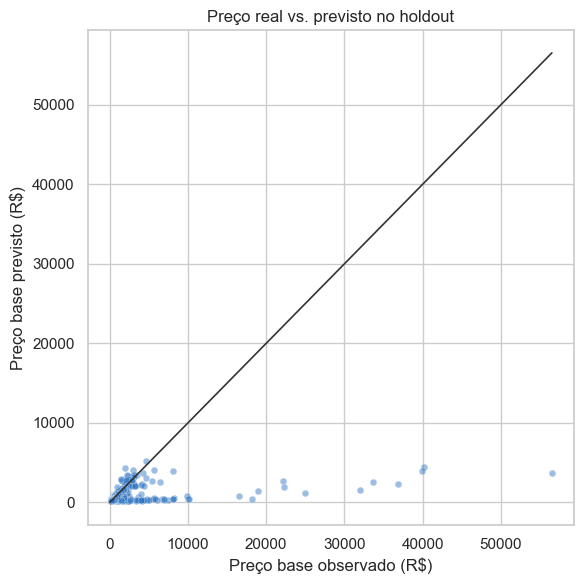

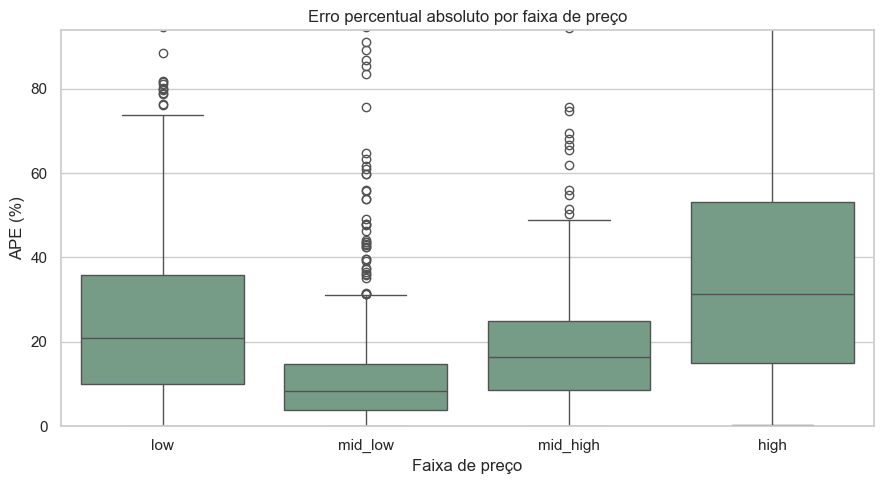

In [10]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=evaluation_df["base_price"], y=evaluation_df["predicted_base_price"], alpha=0.45, s=24, color="#276fbf")
max_axis = max(evaluation_df["base_price"].max(), evaluation_df["predicted_base_price"].max())
plt.plot([0, max_axis], [0, max_axis], color="#333333", linewidth=1.2)
plt.title("Preço real vs. previsto no holdout")
plt.xlabel("Preço base observado (R$)")
plt.ylabel("Preço base previsto (R$)")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_actual_vs_predicted.png", dpi=160)
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=evaluation_df, x="price_band", y="ape", color="#70a288")
plt.ylim(0, min(150, evaluation_df["ape"].quantile(0.98)))
plt.title("Erro percentual absoluto por faixa de preço")
plt.xlabel("Faixa de preço")
plt.ylabel("APE (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_ape_by_price_band.png", dpi=160)
plt.show()

## 7. Interpretação dos drivers

A interpretação combina:

- Importância por permutação no holdout, medindo quanto o MAE piora quando cada feature é embaralhada.
- Cenários contrafactuais para estimar impacto médio de +1 quarto e +1 banheiro mantendo o restante constante.
- Cenário de localização para um apartamento representativo de 1 quarto e 1 banheiro, trocando bairro e coordenadas para medianas dos bairros.

,feature,importance_mae,importance_std
0,bathrooms_model,63.526,2.142
1,lon,26.995,0.941
2,lat,25.637,1.039
3,bedrooms_model,23.269,1.261
4,has_beach,17.014,0.627
5,distance_to_market_center_km,8.801,0.415
6,guests_model,7.602,0.728
7,is_superhost_int,1.471,0.925
8,has_metro,1.336,0.635
9,title_word_count,1.298,0.128


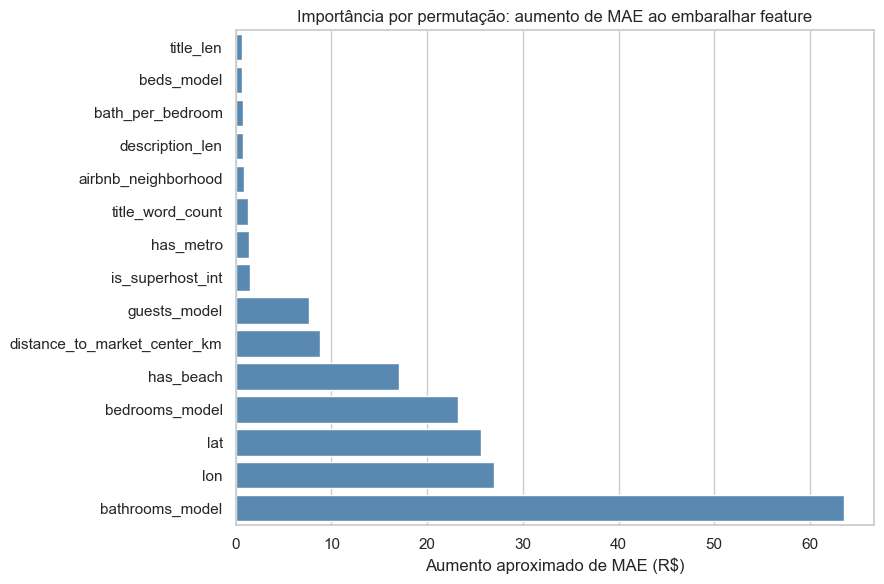

In [11]:
def negative_mae_original_scale(estimator, X, y_log):
    y_true = np.exp(y_log)
    y_pred = np.exp(estimator.predict(X))
    return -mean_absolute_error(y_true, y_pred)


permutation = permutation_importance(
    best_model,
    X_test,
    np.log(y_test),
    scoring=negative_mae_original_scale,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

feature_importance = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mae": permutation.importances_mean,
            "importance_std": permutation.importances_std,
        }
    )
    .sort_values("importance_mae", ascending=False)
    .reset_index(drop=True)
)
feature_importance.to_csv(TABLE_DIR / "feature_importance.csv", index=False)

display(feature_importance.head(20).round(3))

plot_imp = feature_importance.head(15).sort_values("importance_mae")
plt.figure(figsize=(9, 6))
sns.barplot(data=plot_imp, x="importance_mae", y="feature", color="#4b8bbe")
plt.title("Importância por permutação: aumento de MAE ao embaralhar feature")
plt.xlabel("Aumento aproximado de MAE (R$)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_permutation_importance.png", dpi=160)
plt.show()

In [12]:
def update_derived_features(data):
    out = data.copy()
    out["bedrooms_model"] = out["bedrooms_model"].clip(1, 10)
    out["bathrooms_model"] = out["bathrooms_model"].clip(0.5, 10)
    out["beds_model"] = out["beds_model"].clip(1, 30)
    out["guests_model"] = out["guests_model"].clip(1, 16)
    out["bath_per_bedroom"] = out["bathrooms_model"] / out["bedrooms_model"].clip(lower=1)
    out["beds_per_guest"] = out["beds_model"] / out["guests_model"].clip(lower=1)
    out["guests_per_bedroom"] = out["guests_model"] / out["bedrooms_model"].clip(lower=1)
    return out


scenario_rows = []

bedroom_mask = test_df["bedrooms_model"] < 10
x0 = test_df.loc[bedroom_mask, feature_cols].copy()
x1 = update_derived_features(x0.assign(bedrooms_model=x0["bedrooms_model"] + 1))
p0 = np.exp(best_model.predict(x0))
p1 = np.exp(best_model.predict(x1[feature_cols]))
delta = p1 - p0
scenario_rows.append(
    {
        "scenario": "+1 bedroom, demais variáveis constantes",
        "n": int(bedroom_mask.sum()),
        "median_delta_rs": float(np.median(delta)),
        "mean_delta_rs": float(np.mean(delta)),
        "median_delta_pct": float(np.median(delta / p0 * 100)),
        "mean_delta_pct": float(np.mean(delta / p0 * 100)),
    }
)

bathroom_mask = test_df["bathrooms_model"] < 10
x0 = test_df.loc[bathroom_mask, feature_cols].copy()
x1 = update_derived_features(x0.assign(bathrooms_model=x0["bathrooms_model"] + 1))
p0 = np.exp(best_model.predict(x0))
p1 = np.exp(best_model.predict(x1[feature_cols]))
delta = p1 - p0
scenario_rows.append(
    {
        "scenario": "+1 bathroom, demais variáveis constantes",
        "n": int(bathroom_mask.sum()),
        "median_delta_rs": float(np.median(delta)),
        "mean_delta_rs": float(np.mean(delta)),
        "median_delta_pct": float(np.median(delta / p0 * 100)),
        "mean_delta_pct": float(np.mean(delta / p0 * 100)),
    }
)

scenario_impacts = pd.DataFrame(scenario_rows)
scenario_impacts.to_csv(TABLE_DIR / "scenario_impacts.csv", index=False)
display(scenario_impacts.round(2))

,scenario,n,median_delta_rs,mean_delta_rs,median_delta_pct,mean_delta_pct
0,"+1 bedroom, demais variáveis constantes",2124,14.52,28.86,4.97,7.33
1,"+1 bathroom, demais variáveis constantes",2124,119.55,138.15,42.49,42.88


In [13]:
# Apartamento representativo para simular mudança de localização.
representative = {col: train_df[col].median() for col in numeric_features}
representative.update({col: train_df[col].mode().iloc[0] for col in categorical_features})
representative = pd.DataFrame([representative])
representative["guests_model"] = 2
representative["bedrooms_model"] = 1
representative["beds_model"] = 1
representative["bathrooms_model"] = 1
representative = update_derived_features(representative)

neighborhood_stats = (
    train_df.groupby("airbnb_neighborhood")
    .agg(
        train_n=("id", "size"),
        med_lat=("lat", "median"),
        med_lon=("lon", "median"),
        med_dist=("distance_to_market_center_km", "median"),
        observed_median=("base_price", "median"),
    )
    .query("train_n >= 40")
)

location_rows = []
for neighborhood, row in neighborhood_stats.iterrows():
    scenario = representative.copy()
    scenario["airbnb_neighborhood"] = neighborhood
    scenario["lat"] = row["med_lat"]
    scenario["lon"] = row["med_lon"]
    scenario["distance_to_market_center_km"] = row["med_dist"]
    predicted = float(np.exp(best_model.predict(scenario[feature_cols]))[0])
    location_rows.append(
        {
            "airbnb_neighborhood": neighborhood,
            "train_n": int(row["train_n"]),
            "observed_median": float(row["observed_median"]),
            "predicted_representative_price": predicted,
        }
    )

location_effects = pd.DataFrame(location_rows)
location_effects_no_generic = location_effects.loc[location_effects["airbnb_neighborhood"].str.lower() != "são paulo"].copy()
location_effects_no_generic = location_effects_no_generic.sort_values("predicted_representative_price", ascending=False).reset_index(drop=True)
location_effects_no_generic.to_csv(TABLE_DIR / "location_effects.csv", index=False)

print("Maiores preços previstos para apartamento representativo, excluindo label genérico 'São Paulo':")
display(location_effects_no_generic.head(15).round(2))
print("Menores preços previstos para apartamento representativo:")
display(location_effects_no_generic.tail(15).round(2))

Maiores preços previstos para apartamento representativo, excluindo label genérico 'São Paulo':


,airbnb_neighborhood,train_n,observed_median,predicted_representative_price
0,Morumbi,43,418.83,350.10
1,Vila Olímpia,181,402.33,336.67
2,Pinheiros,332,313.20,314.29
3,Alvinópolis,109,359.00,307.02
4,Butantã,51,301.87,300.64
5,Jardim Paulista,327,336.00,297.07
6,Tatuapé,127,276.20,289.33
7,Lapa,48,239.63,280.71
8,Paraíso,47,340.67,267.79
9,Santo Amaro,226,269.47,264.25


Menores preços previstos para apartamento representativo:


,airbnb_neighborhood,train_n,observed_median,predicted_representative_price
21,Vila Mariana,303,238.53,223.25
22,Centro,57,241.80,222.80
23,República,290,225.25,221.72
24,Bela Vista,254,276.00,218.93
25,Campo Belo,152,236.40,217.56
26,Riviera De Sao Lourenco,188,2139.13,214.18
27,Vila Guilherme,41,280.60,213.67
28,Bertioga,84,2706.77,212.38
29,Sé,53,195.67,211.80
30,Santa Cecília,87,269.80,209.56


## 8. Artefatos de produção e resumo executivo

O objeto salvo em `models/base_price_model.joblib` contém o pipeline de pré-processamento tabular e o modelo final. A engenharia de features anterior ao pipeline (`bathrooms_num`, distância, `market_segment`, flags de texto e razões estruturais) está documentada neste notebook e deve ser empacotada como transformação versionada em produção.

Atenção para testes manuais: o artefato salvo contém um único modelo final. Antes do `predict`, é obrigatório aplicar a mesma feature engineering para criar colunas derivadas como `bedrooms_model`, `guests_model`, `beds_model` e `bathrooms_model`. Esses campos são **features de entrada criadas no preprocessing**.

Portanto, mudar apenas `bedrooms`, `guests`, `beds` ou `bathrooms` em um dataframe já processado pode não alterar a previsão se as features derivadas não forem recalculadas. Também há caps robustos: por exemplo, 12 quartos vira `bedrooms_model = 10`, para evitar extrapolação instável fora da amostra.




In [14]:
production_model = best_model
production_model.fit(model_df[feature_cols], np.log(model_df["base_price"]))

model_artifact = {
    "model_name": best_model_name,
    "pipeline": production_model,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "feature_cols": feature_cols,
    "market_center_lat": float(market_center_lat),
    "market_center_lon": float(market_center_lon),
    "row_price_low": float(row_price_low),
    "row_price_high": float(row_price_high),
    "target_low": float(target_low),
    "target_high": float(target_high),
    "max_training_distance_km": 150.0,
    "structural_caps": {"guests": 16, "bedrooms": 10, "beds": 30, "bathrooms": 10},
}
joblib.dump(model_artifact, MODEL_DIR / "base_price_model.joblib")

best_metrics = metrics_df.loc[metrics_df["model"].eq(best_model_name)].iloc[0].to_dict()
summary = {
    "final_model": best_model_name,
    "n_modeling_rows": int(len(model_df)),
    "n_train": int(len(train_df)),
    "n_test": int(len(test_df)),
    "row_price_filter": {"p001": float(row_price_low), "p999": float(row_price_high)},
    "target_range": {"min": float(target_low), "max": float(target_high)},
    "segment_counts": model_df["market_segment"].value_counts().to_dict(),
    "market_center": {"lat": float(market_center_lat), "lon": float(market_center_lon)},
    "metrics": {k: float(v) if isinstance(v, (int, float, np.number)) else v for k, v in best_metrics.items()},
    "top_features": feature_importance.head(10).to_dict(orient="records"),
    "scenario_impacts": scenario_impacts.to_dict(orient="records"),
}
with open(OUT / "project_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Artefatos salvos:")
print(f"- {MODEL_DIR / 'base_price_model.joblib'}")
print(f"- {OUT / 'project_summary.json'}")
print(f"- {TABLE_DIR}")
print(f"- {FIG_DIR}")
display(pd.DataFrame([summary["metrics"]]).round(3))

Artefatos salvos:
- D:\dev\portfolio-pricing\models\base_price_model.joblib
- D:\dev\portfolio-pricing\outputs\project_summary.json
- D:\dev\portfolio-pricing\outputs\tables
- D:\dev\portfolio-pricing\outputs\figures


,model,MAE,RMSE,MAPE,MdAPE,R2_log,Bias
0,robust_segmented_hgb_log_mae,353.961,2362.68,23.866,16.605,0.517,-282.648


## 9. Melhorias propostas: faixas de incerteza e comparáveis

O artefato gerado por este notebook é o modelo final do projeto: `models/base_price_model.joblib`. Como melhoria futura, eu adicionaria camadas complementares para lidar com imóveis grandes, cauda premium e bairros heterogêneos.

Proposta de arquitetura:

- manter um modelo global p50 em log-preço como âncora estável;
- treinar modelos p75 e p90 para expor faixa de incerteza/cauda;
- treinar estimadores p50 por segmento quando houver amostra suficiente (`urban_compact`, `urban_family`, `urban_large`, `beach_premium`, `extended_market`);
- adicionar um classificador de cauda/premium, por exemplo `acima do p75 do bairro/segmento`;
- adicionar uma camada de comparáveis por bairro, estrutura e segmento.

Por que isso ajudaria:

- o ponto p50 preserva estabilidade e interpretabilidade;
- p75/p90 evitam falsa precisão em imóveis de cauda, como unidades premium ou muito acima do padrão do bairro;
- comparáveis locais ajudam quando há boa densidade de exemplos em um bairro;
- o classificador premium cria um gatilho de revisão humana ou de uso de preço mais conservador/agressivo.

Em produção, eu não automatizaria apenas um número para imóveis fora da distribuição. A recomendação seria retornar `preço p50`, `faixa p75/p90`, comparáveis e flags de revisão.




## 10. Conclusões

- O preço base foi definido no nível do anúncio, usando mediana robusta das cotações por `id`.
- `check_in`, `check_out`, `los` e `reference_date` foram excluídos das features finais para evitar modelagem dinâmica; eles foram usados apenas na auditoria/construção do alvo.
- O modelo final é interpretável por importâncias, cenários contrafactuais e avaliação por segmentos.
- A cauda alta foi mantida no treinamento, mas imóveis premium/luxo e praia têm maior erro e devem ter monitoramento/governança separados.
- Como melhoria futura, camadas de segmentos, comparáveis e intervalos p50/p75/p90 podem reduzir falsa precisão em imóveis de cauda.
- Para produção, a recomendação é versionar a transformação de features, monitorar drift por cidade/bairro/faixa de preço e reestimar o alvo com novas cotações periodicamente.




## 11. Extensão futura para dynamic pricing

Este projeto modela apenas o preço base estrutural. Para evoluir para dynamic pricing, a arquitetura recomendada é multiplicativa:

`preço final = preço base estrutural × fator sazonal × fator evento × fator antecedência × fator LOS × fator ocupação × restrições comerciais`

Componentes futuros:

- sazonalidade por cidade, bairro, dia da semana e mês;
- calendário de feriados e eventos;
- curvas de antecedência e last-minute;
- elasticidade por LOS;
- ajuste por ocupação, pickup e inventário;
- backtesting com ADR, RevPAR, ocupação e receita total;
- testes A/B ou experimentos controlados antes de automatizar mudanças de preço.

O ponto importante é manter a separação: o modelo deste notebook estima valor estrutural; os fatores dinâmicos devem entrar como multiplicadores ou camadas posteriores, monitoradas separadamente.

